In [ ]:
from google.colab import drive
drive.mount('/content/drive')
results_dir = '/content/drive/MyDrive/Single Sounds Study/Combined Results'

Mounted at /content/drive


In [ ]:
!pip install researchpy

In [ ]:
import sys
import os
import csv

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.backends.backend_pdf import PdfPages
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import researchpy as rp

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('punkt_tab')



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# Adding in the story and context data for cosine similarity matrix anaylsis

In [ ]:
print(f"DataFrame 'story_df' loaded from '{STORY_DATA_PATH}'. First 5 rows:")
print(story_df.head())
print(f"DataFrame 'context_df' loaded from '{CONTEXT_DATA_PATH}'. First 5 rows:")
print(context_df.head())

DataFrame 'story_df' loaded from '/content/drive/MyDrive/Single Sounds Study/Dataframes/Story_NLP_df_with_cleaned_text_V2.csv'. First 5 rows:
       ID                                           Response  song Duration  \
0  1003.0  I imagine someone hitting a really small gong ...     1   500 ms   
1  1010.0  Sounded like a marimba note or some percussion...     1   500 ms   
2  1015.0  I can imagine a story where a person is at a h...     1   500 ms   
3  1009.0  This sound goes off when a pilot on a plane is...     1   500 ms   
4  1016.0  The sound reminded me of a bee, and I immediat...     1   500 ms   

  Timbre warble AttackTimes  \
0   sine   none        fast   
1   sine   none        fast   
2   sine   none        fast   
3   sine   none        fast   
4   sine   none        fast   

                                    Clean_Lemma_Text  Word_Count  \
0  i imagine someone hitting a really small gong ...          32   
1  sounded like a marimba note or some percussion...        

### project into TF-IDF


In [ ]:
# Extract and combine cleaned texts from both dataframes
context_texts = context_df['cleaned_text'].dropna().tolist()
story_texts = story_df['cleaned_text'].dropna().tolist()
combined_texts = context_texts + story_texts

# Re-initialize and fit the global_vectorizer on the combined corpus
global_vectorizer = TfidfVectorizer(
    analyzer='word',
    min_df=1,
    max_df=0.8
).fit(combined_texts)

print("Global TF-IDF vectorizer initialized and fitted on combined 'context' and 'story' data.")
print(f"Vocabulary size: {len(global_vectorizer.vocabulary_)}")

Global TF-IDF vectorizer initialized and fitted on combined 'context' and 'story' data.
Vocabulary size: 3258


In [ ]:
# 1. Aggregate the 'cleaned_text' responses from the 'df' DataFrame by 'song'
docs_by_song_context = (
    context_df
    .groupby('song')['cleaned_text']
    .apply(lambda xs: ' '.join(xs.dropna().astype(str)))
    .reset_index()
    .rename(columns={'cleaned_text': 'doc'})
)

print("Aggregated 'cleaned_text' for context data (first 5 rows):")
print(docs_by_song_context.head())

# 2. Transform the 'doc' column using the global_vectorizer
song_tfidf_matrix_context = global_vectorizer.transform(docs_by_song_context['doc'])
print("Shape of song_tfidf_matrix_context:", song_tfidf_matrix_context.shape)

# 3. Create a list of song IDs
song_ids_context = docs_by_song_context['song'].tolist()
print("Number of song_ids_context:", len(song_ids_context))

# 4. Calculate the cosine similarity matrix
song_similarity_matrix_context = cosine_similarity(song_tfidf_matrix_context)
song_similarity_df_context = pd.DataFrame(
    song_similarity_matrix_context,
    index=song_ids_context,
    columns=song_ids_context
)

print("Context song-to-song similarity matrix (first 5x5 rows/cols):\n", song_similarity_df_context.iloc[:5, :5])

# 5. Create a metadata DataFrame
meta_context = context_df[['song', 'Duration', 'warble', 'Timbre', 'AttackTimes']].drop_duplicates().set_index('song')

# 6. Ensure the order of meta_context matches song_ids_context
meta_ordered_context = meta_context.loc[song_ids_context]
print("Meta DataFrame for context data (first 5 rows):\n", meta_ordered_context.head())

# 7. Generate pairwise_df_context with feature flags
pairwise_rows_context = []

for i in range(len(song_ids_context)):
    for j in range(i + 1, len(song_ids_context)):
        s1 = song_ids_context[i]
        s2 = song_ids_context[j]

        pairwise_rows_context.append({
            'song1': s1,
            'song2': s2,
            'cosine_similarity': song_similarity_df_context.loc[s1, s2],
            'same_timbre': int(meta_ordered_context.loc[s1, 'Timbre'] == meta_ordered_context.loc[s2, 'Timbre']),
            'same_duration': int(meta_ordered_context.loc[s1, 'Duration'] == meta_ordered_context.loc[s2, 'Duration']),
            'same_warble': int(meta_ordered_context.loc[s1, 'warble'] == meta_ordered_context.loc[s2, 'warble']),
            'same_attack': int(meta_ordered_context.loc[s1, 'AttackTimes'] == meta_ordered_context.loc[s2, 'AttackTimes']),
        })

pairwise_df_context = pd.DataFrame(pairwise_rows_context)

print("Pairwise comparison DataFrame for context data (first 5 rows):\n", pairwise_df_context.head())

Aggregated 'cleaned_text' for context data (first 5 rows):
   song                                                doc
0     1  elevator close genuinely scenario encounter ma...
1     2  door open automatically difficulty scenario en...
2     5  water faucet turn sweep sand round except base...
3     6  small item little bead pour container broom sw...
4     9  room produce introduction podcast kind train b...
Shape of song_tfidf_matrix_context: (8, 3258)
Number of song_ids_context: 8
Context song-to-song similarity matrix (first 5x5 rows/cols):
           1         2         5         6         9
1  1.000000  0.550762  0.226162  0.150208  0.517576
2  0.550762  1.000000  0.298389  0.274127  0.457578
5  0.226162  0.298389  1.000000  0.465260  0.235487
6  0.150208  0.274127  0.465260  1.000000  0.171673
9  0.517576  0.457578  0.235487  0.171673  1.000000
Meta DataFrame for context data (first 5 rows):
      Duration warble Timbre AttackTimes
song                                   
1      

In [ ]:
# 1. Aggregate the 'cleaned_text' responses from the 'story_df' DataFrame by 'song'
docs_by_song_story = (
    story_df
    .groupby('song')['cleaned_text']
    .apply(lambda xs: ' '.join(xs.dropna().astype(str)))
    .reset_index()
    .rename(columns={'cleaned_text': 'doc'})
)

print("Aggregated 'cleaned_text' for story data (first 5 rows):")
print(docs_by_song_story.head())

# 2. Transform the 'doc' column using the global_vectorizer
song_tfidf_matrix_story = global_vectorizer.transform(docs_by_song_story['doc'])
print("Shape of song_tfidf_matrix_story:", song_tfidf_matrix_story.shape)

# 3. Create a list of song IDs
song_ids_story = docs_by_song_story['song'].tolist()
print("Number of song_ids_story:", len(song_ids_story))

# 4. Calculate the cosine similarity matrix
song_similarity_matrix_story = cosine_similarity(song_tfidf_matrix_story)
song_similarity_df_story = pd.DataFrame(
    song_similarity_matrix_story,
    index=song_ids_story,
    columns=song_ids_story
)

print("Story song-to-song similarity matrix (first 5x5 rows/cols):\n", song_similarity_df_story.iloc[:5, :5])

# 5. Create a metadata DataFrame (using story_df for features, ensuring uniqueness)
meta_story = story_df[['song', 'Duration', 'warble', 'Timbre', 'AttackTimes']].drop_duplicates().set_index('song')

# 6. Ensure the order of meta_story matches song_ids_story
meta_ordered_story = meta_story.loc[song_ids_story]
print("Meta DataFrame for story data (first 5 rows):\n", meta_ordered_story.head())

# 7. Generate pairwise_df_story with feature flags
pairwise_rows_story = []

for i in range(len(song_ids_story)):
    for j in range(i + 1, len(song_ids_story)):
        s1 = song_ids_story[i]
        s2 = song_ids_story[j]

        pairwise_rows_story.append({
            'song1': s1,
            'song2': s2,
            'cosine_similarity': song_similarity_df_story.loc[s1, s2],
            'same_timbre': int(meta_ordered_story.loc[s1, 'Timbre'] == meta_ordered_story.loc[s2, 'Timbre']),
            'same_duration': int(meta_ordered_story.loc[s1, 'Duration'] == meta_ordered_story.loc[s2, 'Duration']),
            'same_warble': int(meta_ordered_story.loc[s1, 'warble'] == meta_ordered_story.loc[s2, 'warble']),
            'same_attack': int(meta_ordered_story.loc[s1, 'AttackTimes'] == meta_ordered_story.loc[s2, 'AttackTimes']),
        })

pairwise_df_story = pd.DataFrame(pairwise_rows_story)

print("Pairwise comparison DataFrame for story data (first 5 rows):\n", pairwise_df_story.head())

Aggregated 'cleaned_text' for story data (first 5 rows):
   song                                                doc
0     1  hit really small gong drum mallet really short...
1     2  young home party blow air glass water radial t...
2     5  either sink metal brush use drum sometimes imm...
3     6  television static somebody night sit dark alon...
4     9  dad honk car another person honk u meditate te...
Shape of song_tfidf_matrix_story: (8, 3258)
Number of song_ids_story: 8
Story song-to-song similarity matrix (first 5x5 rows/cols):
           1         2         5         6         9
1  1.000000  0.404417  0.331009  0.272237  0.452439
2  0.404417  1.000000  0.270735  0.303318  0.405428
5  0.331009  0.270735  1.000000  0.475870  0.289878
6  0.272237  0.303318  0.475870  1.000000  0.288010
9  0.452439  0.405428  0.289878  0.288010  1.000000
Meta DataFrame for story data (first 5 rows):
      Duration warble Timbre AttackTimes
song                                   
1      500 ms   n

## take cosine similarity for same and different features


In [ ]:
feature_comparison_results = []

# Process context data
for feature in ['same_timbre', 'same_duration', 'same_warble', 'same_attack']:
    same_feature_similarity = pairwise_df_context[pairwise_df_context[feature] == 1]['cosine_similarity'].mean()
    diff_feature_similarity = pairwise_df_context[pairwise_df_context[feature] == 0]['cosine_similarity'].mean()
    feature_comparison_results.append({
        'corpus': 'context',
        'feature': feature,
        'mean_similarity_same': same_feature_similarity,
        'mean_similarity_different': diff_feature_similarity
    })

# Process story data
for feature in ['same_timbre', 'same_duration', 'same_warble', 'same_attack']:
    same_feature_similarity = pairwise_df_story[pairwise_df_story[feature] == 1]['cosine_similarity'].mean()
    diff_feature_similarity = pairwise_df_story[pairwise_df_story[feature] == 0]['cosine_similarity'].mean()
    feature_comparison_results.append({
        'corpus': 'story',
        'feature': feature,
        'mean_similarity_same': same_feature_similarity,
        'mean_similarity_different': diff_feature_similarity
    })

feature_comparison_df = pd.DataFrame(feature_comparison_results)
print("Feature-based similarity comparison (Context vs. Story):")
print(feature_comparison_df)

Feature-based similarity comparison (Context vs. Story):
    corpus        feature  mean_similarity_same  mean_similarity_different
0  context    same_timbre              0.475222                   0.236898
1  context  same_duration              0.412916                   0.343208
2  context    same_warble              0.375046                   0.370466
3  context    same_attack              0.356632                   0.385421
4    story    same_timbre              0.401692                   0.280572
5    story  same_duration              0.392662                   0.317624
6    story    same_warble              0.379967                   0.309537
7    story    same_attack              0.339020                   0.357855


### context data only

/tmp/ipykernel_3245/1913267888.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Similarity Type', y='Cosine Similarity', data=plot_data, palette={'Same ' + feature_name_display: 'skyblue', 'Different ' + feature_name_display: 'salmon'})


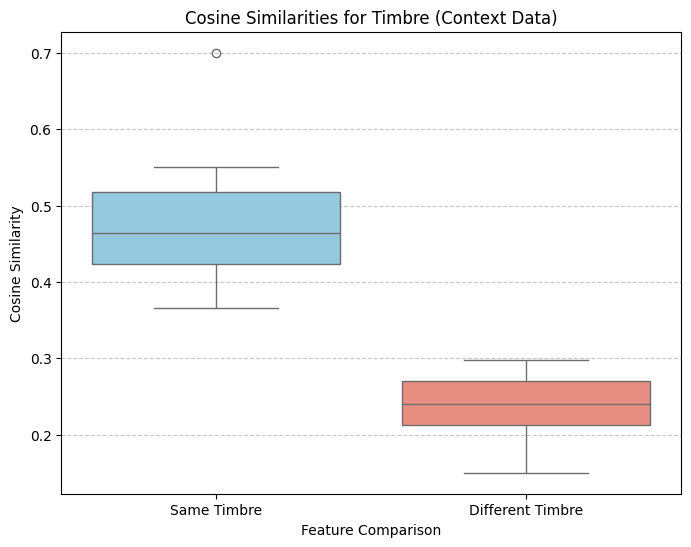

/usr/local/lib/python3.12/dist-packages/researchpy/ttest.py:301: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'same' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.iloc[0,0] = group1_name
/usr/local/lib/python3.12/dist-packages/researchpy/ttest.py:460: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Difference (same - different) = ' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table2.iloc[0,0] = f"Difference ({group1_name} - {group2_name}) = "
/tmp/ipykernel_3245/1913267888.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Similarity Type', y='Cosine Similarity', data=plot_dat


--- Timbre Analysis ---
T-statistic: 9.609
P-value: 0.000
df value: 24.009
                     Welch's t-test  results
0  Difference (same - different) =    0.2383
1             Degrees of freedom =   25.4031
2                              t =    9.6092
3          Two side test p value =    0.0000
4         Difference < 0 p value =    1.0000
5         Difference > 0 p value =    0.0000
6                      Cohen's d =    3.3838
7                      Hedge's g =    3.2852
8                 Glass's delta1 =    2.8327
9               Point-Biserial r =    0.8856
    Variable     N      Mean        SD        SE  95% Conf.  Interval
0       same  16.0  0.475222  0.084133  0.021033   0.430391  0.520054
1  different  12.0  0.236898  0.045526  0.013142   0.207972  0.265824
2   combined  28.0  0.373083  0.138571  0.026187   0.319351  0.426815
There is a statistically significant difference between mean similarities for 'same' and 'different' timbre (p < 0.05).


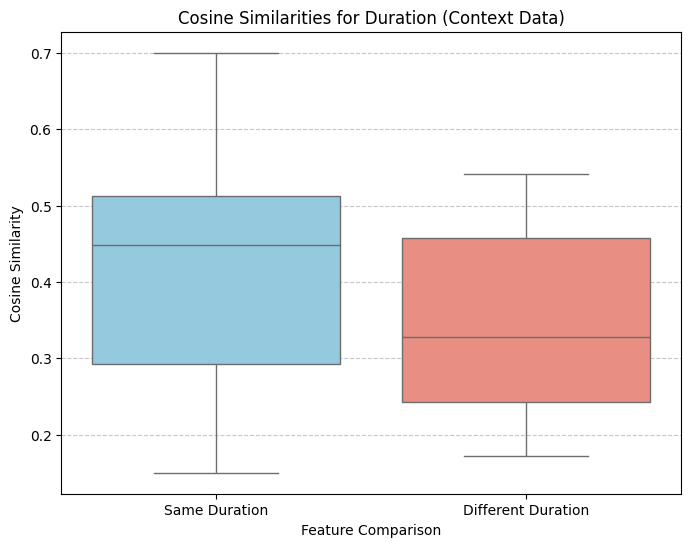


--- Duration Analysis ---
T-statistic: 1.288
P-value: 0.212
df value: 20.192
                     Welch's t-test  results
0  Difference (same - different) =    0.0697
1             Degrees of freedom =   21.7308
2                              t =    1.2883
3          Two side test p value =    0.2112
4         Difference < 0 p value =    0.8944
5         Difference > 0 p value =    0.1056
6                      Cohen's d =    0.5103
7                      Hedge's g =    0.4955
8                 Glass's delta1 =    0.4483
9               Point-Biserial r =    0.2664
    Variable     N      Mean        SD        SE  95% Conf.  Interval
0       same  12.0  0.412916  0.155479  0.044883   0.314129  0.511703
1  different  16.0  0.343208  0.120891  0.030223   0.278790  0.407627
2   combined  28.0  0.373083  0.138571  0.026187   0.319351  0.426815
There is no statistically significant difference between mean similarities for 'same' and 'different' duration (p >= 0.05).


/usr/local/lib/python3.12/dist-packages/researchpy/ttest.py:301: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'same' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.iloc[0,0] = group1_name
/usr/local/lib/python3.12/dist-packages/researchpy/ttest.py:460: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Difference (same - different) = ' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table2.iloc[0,0] = f"Difference ({group1_name} - {group2_name}) = "
/tmp/ipykernel_3245/1913267888.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Similarity Type', y='Cosine Similarity', data=plot_dat

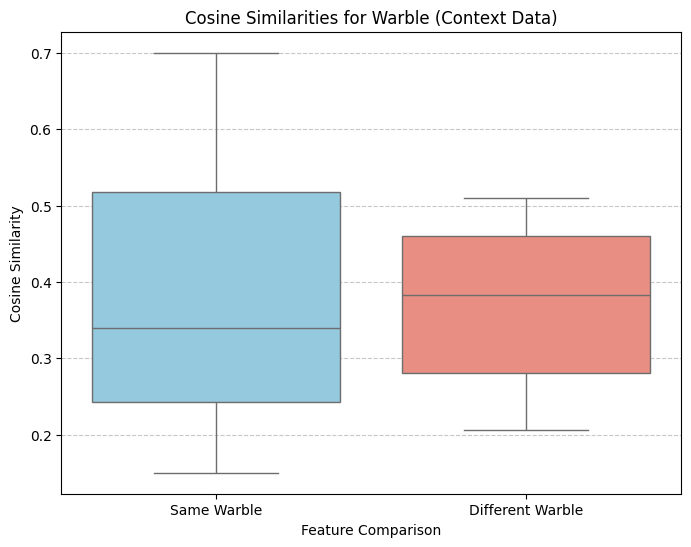

/usr/local/lib/python3.12/dist-packages/researchpy/ttest.py:301: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'same' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.iloc[0,0] = group1_name
/usr/local/lib/python3.12/dist-packages/researchpy/ttest.py:460: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Difference (same - different) = ' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table2.iloc[0,0] = f"Difference ({group1_name} - {group2_name}) = "
/tmp/ipykernel_3245/1913267888.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Similarity Type', y='Cosine Similarity', data=plot_dat


--- Warble Analysis ---
T-statistic: 0.090
P-value: 0.929
df value: 25.519
                     Welch's t-test  results
0  Difference (same - different) =    0.0046
1             Degrees of freedom =   27.2728
2                              t =    0.0903
3          Two side test p value =    0.9287
4         Difference < 0 p value =    0.5357
5         Difference > 0 p value =    0.4643
6                      Cohen's d =    0.0324
7                      Hedge's g =    0.0315
8                 Glass's delta1 =    0.0281
9               Point-Biserial r =    0.0173
    Variable     N      Mean        SD        SE  95% Conf.  Interval
0       same  16.0  0.375046  0.162844  0.040711   0.288272  0.461820
1  different  12.0  0.370466  0.104678  0.030218   0.303957  0.436975
2   combined  28.0  0.373083  0.138571  0.026187   0.319351  0.426815
There is no statistically significant difference between mean similarities for 'same' and 'different' warble (p >= 0.05).


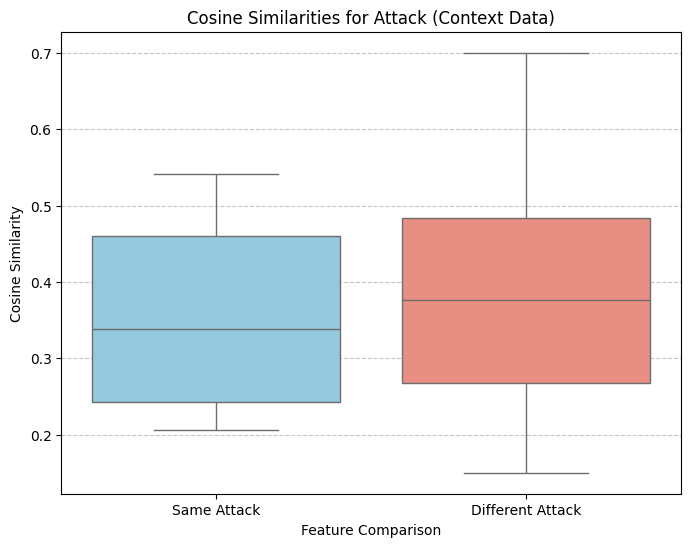


--- Attack Analysis ---
T-statistic: -0.553
P-value: 0.585
df value: 25.771
                     Welch's t-test  results
0  Difference (same - different) =   -0.0288
1             Degrees of freedom =   27.8400
2                              t =   -0.5531
3          Two side test p value =    0.5846
4         Difference < 0 p value =    0.2923
5         Difference > 0 p value =    0.7077
6                      Cohen's d =   -0.2050
7                      Hedge's g =   -0.1990
8                 Glass's delta1 =   -0.2330
9               Point-Biserial r =   -0.1043
    Variable     N      Mean        SD        SE  95% Conf.  Interval
0       same  12.0  0.356632  0.123557  0.035668   0.278128  0.435136
1  different  16.0  0.385421  0.151622  0.037905   0.304628  0.466215
2   combined  28.0  0.373083  0.138571  0.026187   0.319351  0.426815
There is no statistically significant difference between mean similarities for 'same' and 'different' attack (p >= 0.05).


/usr/local/lib/python3.12/dist-packages/researchpy/ttest.py:301: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'same' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.iloc[0,0] = group1_name
/usr/local/lib/python3.12/dist-packages/researchpy/ttest.py:460: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Difference (same - different) = ' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table2.iloc[0,0] = f"Difference ({group1_name} - {group2_name}) = "


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# Define a list of features to analyze
features_to_analyze = ['same_timbre', 'same_duration', 'same_warble', 'same_attack']

for feature in features_to_analyze:
    # Filter pairwise_df_context for 'same' and 'different' feature similarities
    same_feature_similarities = pairwise_df_context[pairwise_df_context[feature] == 1]['cosine_similarity'].dropna()
    diff_feature_similarities = pairwise_df_context[pairwise_df_context[feature] == 0]['cosine_similarity'].dropna()

    # Skip if either group is empty
    if same_feature_similarities.empty or diff_feature_similarities.empty:
        print(f"Skipping {feature} due to empty similarity groups.")
        continue

    # Prepare data for box plot
    feature_name_display = feature.replace('same_', '').replace('_', ' ').title()
    plot_data = pd.DataFrame({
        'Similarity Type': [f'Same {feature_name_display}'] * len(same_feature_similarities) +
                           [f'Different {feature_name_display}'] * len(diff_feature_similarities),
        'Cosine Similarity': pd.concat([same_feature_similarities, diff_feature_similarities])
    })

    # Create a single box plot
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Similarity Type', y='Cosine Similarity', data=plot_data, palette={'Same ' + feature_name_display: 'skyblue', 'Different ' + feature_name_display: 'salmon'})
    plt.title(f'Cosine Similarities for {feature_name_display} (Context Data)')
    plt.xlabel('Feature Comparison')
    plt.ylabel('Cosine Similarity')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Perform independent samples t-test
    results = ttest_ind(same_feature_similarities, diff_feature_similarities, equal_var=False) # Welch's t-test assuming unequal variances
    t_stat = results.statistic
    p_value = results.pvalue
    df = results.df
    summary_rp, results_rp = rp.ttest(group1=same_feature_similarities, group1_name="same",
                             group2=diff_feature_similarities, group2_name="different",
                             equal_variances = False, paired=False, welch_dof='welch')

    print(f"\n--- {feature_name_display} Analysis ---")
    print(f"T-statistic: {t_stat:.3f}")
    print(f"P-value: {p_value:.3f}")
    print(f"df value: {df:.3f}")
    print(results_rp)
    print(summary_rp)


    alpha = 0.05
    if p_value < alpha:
        print(f"There is a statistically significant difference between mean similarities for 'same' and 'different' {feature.replace('same_', '').replace('_', ' ').lower()} (p < {alpha}).")
    else:
        print(f"There is no statistically significant difference between mean similarities for 'same' and 'different' {feature.replace('same_', '').replace('_', ' ').lower()} (p >= {alpha}).")

### story data only

/tmp/ipykernel_3245/3427127204.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Similarity Type', y='Cosine Similarity', data=plot_data, palette={'Same ' + feature_name_display: 'skyblue', 'Different ' + feature_name_display: 'salmon'})


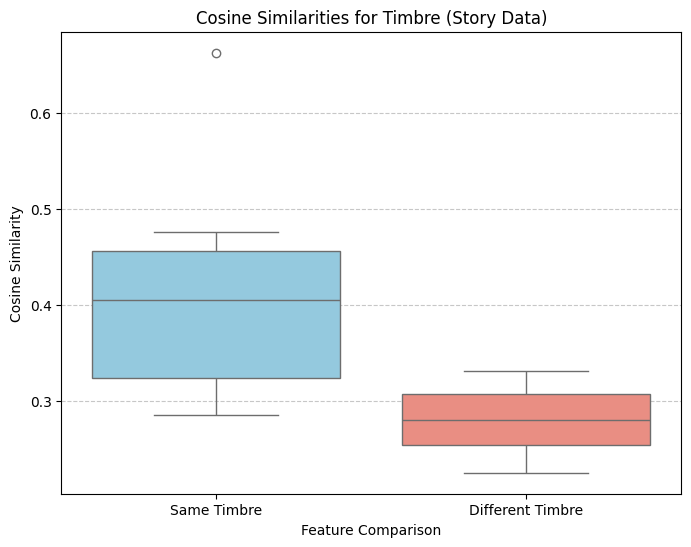

/usr/local/lib/python3.12/dist-packages/researchpy/ttest.py:301: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'same' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.iloc[0,0] = group1_name
/usr/local/lib/python3.12/dist-packages/researchpy/ttest.py:460: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Difference (same - different) = ' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table2.iloc[0,0] = f"Difference ({group1_name} - {group2_name}) = "
/tmp/ipykernel_3245/3427127204.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Similarity Type', y='Cosine Similarity', data=plot_dat


--- Timbre Analysis ---
T-statistic: 4.609
P-value: 0.000
df value: 20.370
                     Welch's t-test  results
0  Difference (same - different) =    0.1211
1             Degrees of freedom =   21.1333
2                              t =    4.6090
3          Two side test p value =    0.0001
4         Difference < 0 p value =    0.9999
5         Difference > 0 p value =    0.0001
6                      Cohen's d =    1.5760
7                      Hedge's g =    1.5301
8                 Glass's delta1 =    1.2597
9               Point-Biserial r =    0.7080
    Variable     N      Mean        SD        SE  95% Conf.  Interval
0       same  16.0  0.401692  0.096147  0.024037   0.350458  0.452925
1  different  12.0  0.280572  0.036793  0.010621   0.257195  0.303949
2   combined  28.0  0.349783  0.097020  0.018335   0.312162  0.387404
There is a statistically significant difference between mean similarities for 'same' and 'different' timbre (p < 0.05).


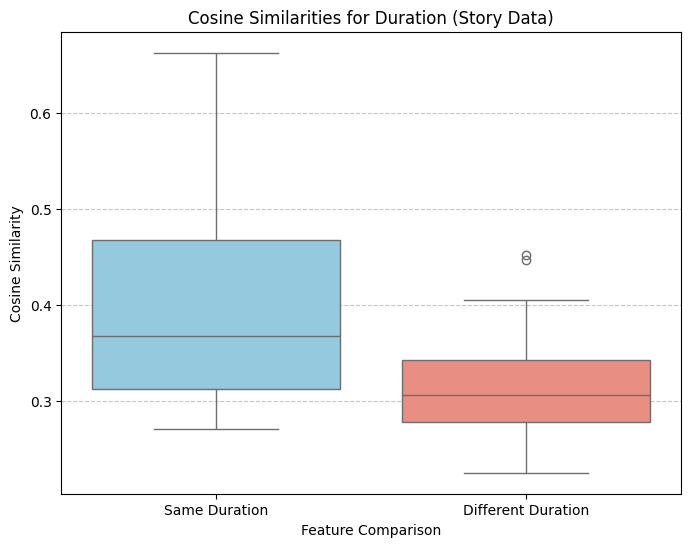

/usr/local/lib/python3.12/dist-packages/researchpy/ttest.py:301: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'same' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.iloc[0,0] = group1_name
/usr/local/lib/python3.12/dist-packages/researchpy/ttest.py:460: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Difference (same - different) = ' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table2.iloc[0,0] = f"Difference ({group1_name} - {group2_name}) = "
/tmp/ipykernel_3245/3427127204.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Similarity Type', y='Cosine Similarity', data=plot_dat


--- Duration Analysis ---
T-statistic: 2.015
P-value: 0.060
df value: 16.970
                     Welch's t-test  results
0  Difference (same - different) =    0.0750
1             Degrees of freedom =   18.0102
2                              t =    2.0148
3          Two side test p value =    0.0591
4         Difference < 0 p value =    0.9704
5         Difference > 0 p value =    0.0296
6                      Cohen's d =    0.8241
7                      Hedge's g =    0.8001
8                 Glass's delta1 =    0.6571
9               Point-Biserial r =    0.4289
    Variable     N      Mean        SD        SE  95% Conf.  Interval
0       same  12.0  0.392662  0.114198  0.032966   0.320104  0.465219
1  different  16.0  0.317624  0.069324  0.017331   0.280684  0.354564
2   combined  28.0  0.349783  0.097020  0.018335   0.312162  0.387404
There is no statistically significant difference between mean similarities for 'same' and 'different' duration (p >= 0.05).


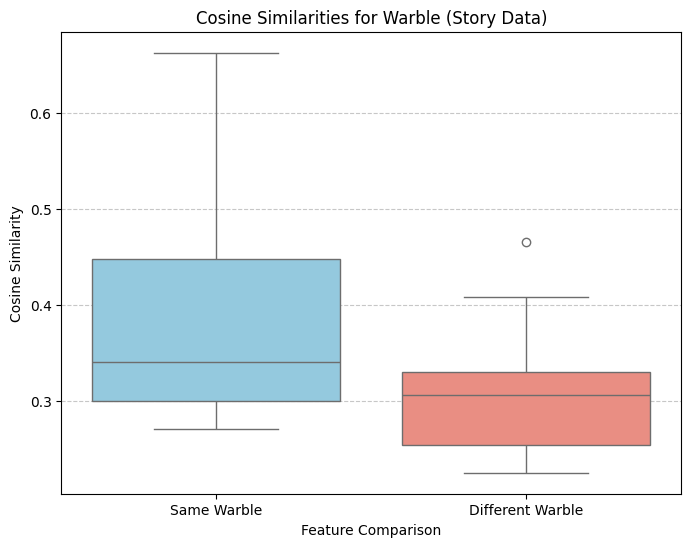

/usr/local/lib/python3.12/dist-packages/researchpy/ttest.py:301: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'same' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.iloc[0,0] = group1_name
/usr/local/lib/python3.12/dist-packages/researchpy/ttest.py:460: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Difference (same - different) = ' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table2.iloc[0,0] = f"Difference ({group1_name} - {group2_name}) = "
/tmp/ipykernel_3245/3427127204.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Similarity Type', y='Cosine Similarity', data=plot_dat


--- Warble Analysis ---
T-statistic: 2.115
P-value: 0.044
df value: 25.838
                     Welch's t-test  results
0  Difference (same - different) =    0.0704
1             Degrees of freedom =   27.7054
2                              t =    2.1151
3          Two side test p value =    0.0436
4         Difference < 0 p value =    0.9782
5         Difference > 0 p value =    0.0218
6                      Cohen's d =    0.7654
7                      Hedge's g =    0.7431
8                 Glass's delta1 =    0.6737
9               Point-Biserial r =    0.3729
    Variable     N      Mean        SD        SE  95% Conf.  Interval
0       same  16.0  0.379967  0.104541  0.026135   0.324261  0.435673
1  different  12.0  0.309537  0.071480  0.020634   0.264121  0.354953
2   combined  28.0  0.349783  0.097020  0.018335   0.312162  0.387404
There is a statistically significant difference between mean similarities for 'same' and 'different' warble (p < 0.05).


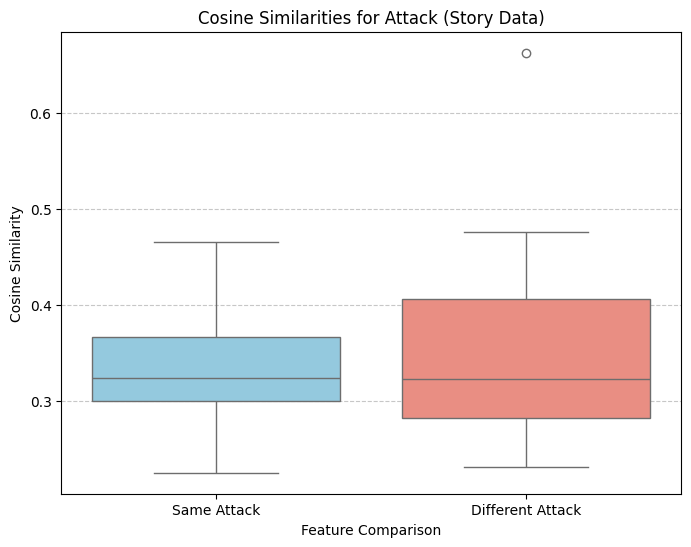


--- Attack Analysis ---
T-statistic: -0.528
P-value: 0.602
df value: 25.868
                     Welch's t-test  results
0  Difference (same - different) =   -0.0188
1             Degrees of freedom =   27.7486
2                              t =   -0.5284
3          Two side test p value =    0.6014
4         Difference < 0 p value =    0.3007
5         Difference > 0 p value =    0.6993
6                      Cohen's d =   -0.1914
7                      Hedge's g =   -0.1859
8                 Glass's delta1 =   -0.2450
9               Point-Biserial r =   -0.0998
    Variable     N      Mean        SD        SE  95% Conf.  Interval
0       same  12.0  0.339020  0.076891  0.022196   0.290166  0.387874
1  different  16.0  0.357855  0.111560  0.027890   0.298409  0.417301
2   combined  28.0  0.349783  0.097020  0.018335   0.312162  0.387404
There is no statistically significant difference between mean similarities for 'same' and 'different' attack (p >= 0.05).


/usr/local/lib/python3.12/dist-packages/researchpy/ttest.py:301: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'same' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.iloc[0,0] = group1_name
/usr/local/lib/python3.12/dist-packages/researchpy/ttest.py:460: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Difference (same - different) = ' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table2.iloc[0,0] = f"Difference ({group1_name} - {group2_name}) = "


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# Define a list of features to analyze (already defined in previous step, reusing it)
# features_to_analyze = ['same_timbre', 'same_duration', 'same_warble', 'same_attack']

for feature in features_to_analyze:
    # Filter pairwise_df_story for 'same' and 'different' feature similarities
    same_feature_similarities = pairwise_df_story[pairwise_df_story[feature] == 1]['cosine_similarity'].dropna()
    diff_feature_similarities = pairwise_df_story[pairwise_df_story[feature] == 0]['cosine_similarity'].dropna()

    # Skip if either group is empty
    if same_feature_similarities.empty or diff_feature_similarities.empty:
        print(f"Skipping {feature} due to empty similarity groups.")
        continue

    # Prepare data for box plot
    feature_name_display = feature.replace('same_', '').replace('_', ' ').title()
    plot_data = pd.DataFrame({
        'Similarity Type': [f'Same {feature_name_display}'] * len(same_feature_similarities) +
                           [f'Different {feature_name_display}'] * len(diff_feature_similarities),
        'Cosine Similarity': pd.concat([same_feature_similarities, diff_feature_similarities])
    })

    # Create a single box plot
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Similarity Type', y='Cosine Similarity', data=plot_data, palette={'Same ' + feature_name_display: 'skyblue', 'Different ' + feature_name_display: 'salmon'})
    plt.title(f'Cosine Similarities for {feature_name_display} (Story Data)')
    plt.xlabel('Feature Comparison')
    plt.ylabel('Cosine Similarity')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Perform independent samples t-test
    results = ttest_ind(same_feature_similarities, diff_feature_similarities, equal_var=False) # Welch's t-test assuming unequal variances
    t_stat = results.statistic
    p_value = results.pvalue
    df = results.df
    summary_rp, results_rp = rp.ttest(group1=same_feature_similarities, group1_name="same",
                             group2=diff_feature_similarities, group2_name="different",
                             equal_variances = False, paired=False, welch_dof='welch')

    print(f"\n--- {feature_name_display} Analysis ---")
    print(f"T-statistic: {t_stat:.3f}")
    print(f"P-value: {p_value:.3f}")
    print(f"df value: {df:.3f}")
    print(results_rp)
    print(summary_rp)

    alpha = 0.05
    if p_value < alpha:
        print(f"There is a statistically significant difference between mean similarities for 'same' and 'different' {feature.replace('same_', '').replace('_', ' ').lower()} (p < {alpha}).")
    else:
        print(f"There is no statistically significant difference between mean similarities for 'same' and 'different' {feature.replace('same_', '').replace('_', ' ').lower()} (p >= {alpha}).")

In [ ]:
# For same_timbre
same_timbre_1_similarity = pairwise_df_story[pairwise_df_story['same_timbre'] == 1]['cosine_similarity']
same_timbre_0_similarity = pairwise_df_story[pairwise_df_story['same_timbre'] == 0]['cosine_similarity']

print(f"--- same_timbre == 1 ---")
print(f"Mean: {same_timbre_1_similarity.mean():.3f}")
print(f"Standard Deviation: {same_timbre_1_similarity.std():.3f}")

print(f"\n--- same_timbre == 0 ---")
print(f"Mean: {same_timbre_0_similarity.mean():.3f}")
print(f"Standard Deviation: {same_timbre_0_similarity.std():.3f}")

# For same_warble
same_warble_1_similarity = pairwise_df_story[pairwise_df_story['same_warble'] == 1]['cosine_similarity']
same_warble_0_similarity = pairwise_df_story[pairwise_df_story['same_warble'] == 0]['cosine_similarity']

print(f"\n--- same_warble == 1 ---")
print(f"Mean: {same_warble_1_similarity.mean():.3f}")
print(f"Standard Deviation: {same_warble_1_similarity.std():.3f}")

print(f"\n--- same_warble == 0 ---")
print(f"Mean: {same_warble_0_similarity.mean():.3f}")
print(f"Standard Deviation: {same_warble_0_similarity.std():.3f}")

--- same_timbre == 1 ---
Mean: 0.402
Standard Deviation: 0.096

--- same_timbre == 0 ---
Mean: 0.281
Standard Deviation: 0.037

--- same_warble == 1 ---
Mean: 0.380
Standard Deviation: 0.105

--- same_warble == 0 ---
Mean: 0.310
Standard Deviation: 0.071


In [ ]:
# For same_timbre
same_timbre_1_similarity = pairwise_df_context[pairwise_df_context['same_timbre'] == 1]['cosine_similarity']
same_timbre_0_similarity = pairwise_df_context[pairwise_df_context['same_timbre'] == 0]['cosine_similarity']

print(f"--- same_timbre == 1 ---")
print(f"Mean: {same_timbre_1_similarity.mean():.3f}")
print(f"Standard Deviation: {same_timbre_1_similarity.std():.3f}")

print(f"\n--- same_timbre == 0 ---")
print(f"Mean: {same_timbre_0_similarity.mean():.3f}")
print(f"Standard Deviation: {same_timbre_0_similarity.std():.3f}")

--- same_timbre == 1 ---
Mean: 0.475
Standard Deviation: 0.084

--- same_timbre == 0 ---
Mean: 0.237
Standard Deviation: 0.046


## Between-Group Similarity

In [ ]:
# 1. Calculate the full cross-corpus cosine similarity matrix
cross_similarity_matrix = cosine_similarity(song_tfidf_matrix_context, song_tfidf_matrix_story)

print(f"Shape of cross_similarity_matrix: {cross_similarity_matrix.shape}")

# 2. Extract the 'same-sound/between-group' similarities (diagonal elements)
same_sound_similarities = np.diag(cross_similarity_matrix)

# 3. Extract the 'different-sound/between-group' similarities (off-diagonal elements)
different_sound_similarities = cross_similarity_matrix[np.eye(cross_similarity_matrix.shape[0], dtype=bool) == False]

print("\nSame-Sound/Between-Group Similarities:")
print(f"First 5 elements: {same_sound_similarities[:5]}")
print(f"Mean: {np.mean(same_sound_similarities):.3f}")

print("\nDifferent-Sound/Between-Group Similarities:")
print(f"First 5 elements: {different_sound_similarities[:5]}")
print(f"Mean: {np.mean(different_sound_similarities):.3f}")

# show somehow printing out and showing what all of those comparisons are containing, explaining each variable?

Shape of cross_similarity_matrix: (8, 8)

Same-Sound/Between-Group Similarities:
First 5 elements: [0.55441037 0.49810577 0.60793549 0.66529242 0.59860225]
Mean: 0.546

Different-Sound/Between-Group Similarities:
First 5 elements: [0.36230448 0.21240032 0.18715188 0.33040303 0.24864452]
Mean: 0.278


/tmp/ipykernel_3245/1027411188.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Similarity Type', y='Cosine Similarity', data=plot_data_between, palette={'Same Sound': 'lightgreen', 'Different Sound': 'salmon'})


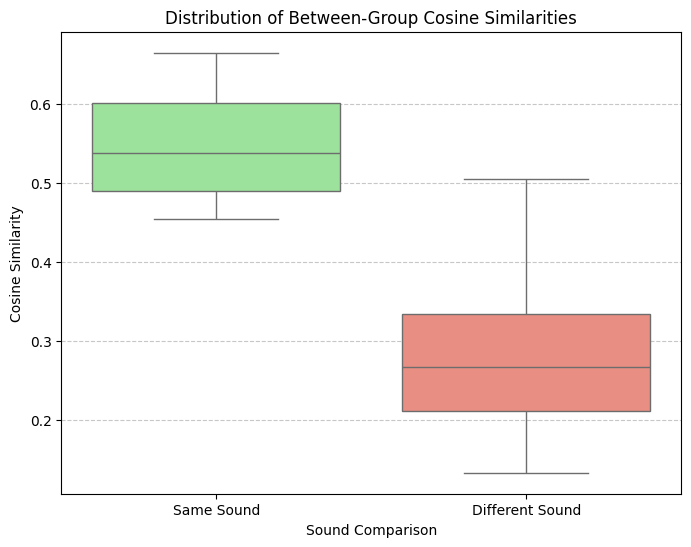


--- Between-Group Similarity Analysis ---
T-statistic: 9.394
P-value: 0.000
df value: 9.695
                     Welch's t-test  results
0  Difference (same - different) =    0.2679
1             Degrees of freedom =   10.4531
2                              t =    9.3938
3          Two side test p value =    0.0000
4         Difference < 0 p value =    1.0000
5         Difference > 0 p value =    0.0000
6                      Cohen's d =    3.2571
7                      Hedge's g =    3.2175
8                 Glass's delta1 =    3.6066
9               Point-Biserial r =    0.9456
    Variable     N      Mean        SD        SE  95% Conf.  Interval
0       same   8.0  0.545691  0.074288  0.026265   0.483585  0.607797
1  different  56.0  0.277760  0.083221  0.011121   0.255473  0.300047
2   combined  64.0  0.311252  0.120979  0.015122   0.281032  0.341471
There is a statistically significant difference between mean similarities for 'same-sound' and 'different-sound' between groups (p <

/usr/local/lib/python3.12/dist-packages/researchpy/ttest.py:301: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'same' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.iloc[0,0] = group1_name
/usr/local/lib/python3.12/dist-packages/researchpy/ttest.py:460: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Difference (same - different) = ' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table2.iloc[0,0] = f"Difference ({group1_name} - {group2_name}) = "


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import pandas as pd

# Prepare data for box plot
plot_data_between = pd.DataFrame({
    'Similarity Type': ['Same Sound'] * len(same_sound_similarities) +
                       ['Different Sound'] * len(different_sound_similarities),
    'Cosine Similarity': pd.concat([pd.Series(same_sound_similarities), pd.Series(different_sound_similarities)])
})

# Create a single box plot for between-group similarities
plt.figure(figsize=(8, 6))
sns.boxplot(x='Similarity Type', y='Cosine Similarity', data=plot_data_between, palette={'Same Sound': 'lightgreen', 'Different Sound': 'salmon'})
plt.title('Distribution of Between-Group Cosine Similarities')
plt.xlabel('Sound Comparison')
plt.ylabel('Cosine Similarity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Perform independent samples t-test
results = ttest_ind(same_sound_similarities, different_sound_similarities, equal_var=False) # Welch's t-test assuming unequal variances
summary_rp, results_rp = rp.ttest(group1=pd.Series(same_sound_similarities), group1_name="same",
                             group2=pd.Series(different_sound_similarities), group2_name="different",
                             equal_variances = False, paired=False, welch_dof='welch')
t_stat = results.statistic
p_value = results.pvalue
df = results.df
print("\n--- Between-Group Similarity Analysis ---")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"df value: {df:.3f}")
print(results_rp)
print(summary_rp)


alpha = 0.05
if p_value < alpha:
    print(f"There is a statistically significant difference between mean similarities for 'same-sound' and 'different-sound' between groups (p < {alpha}).")
else:
    print(f"There is no statistically significant difference between mean similarities for 'same-sound' and 'different-sound' between groups (p >= {alpha}).")

In [ ]:
print("\n--- Between-Group Similarities Statistics ---")
print("Same-Sound/Between-Group Similarities:")
print(f"  Mean: {np.mean(same_sound_similarities):.3f}")
print(f"  Standard Deviation: {np.std(same_sound_similarities):.3f}")

print("\nDifferent-Sound/Between-Group Similarities:")
print(f"  Mean: {np.mean(different_sound_similarities):.3f}")
print(f"  Standard Deviation: {np.std(different_sound_similarities):.3f}")


--- Between-Group Similarities Statistics ---
Same-Sound/Between-Group Similarities:
  Mean: 0.546
  Standard Deviation: 0.069

Different-Sound/Between-Group Similarities:
  Mean: 0.278
  Standard Deviation: 0.082


## Combined Plotting

In [ ]:
from scipy.stats import ttest_ind

# 1. Initialize empty lists
all_plot_data = []
all_p_values_df = []

# Define a list of features to analyze (reusing from previous steps)
features_to_analyze = ['same_timbre', 'same_duration', 'same_warble', 'same_attack']

# Tuple of corpus name and its corresponding pairwise_df
corpus_data = [
    ('context', pairwise_df_context),
    ('story', pairwise_df_story)
]

# 2. Iterate through each feature
for feature in features_to_analyze:
    # Format feature name for plotting
    feature_name_display = feature.replace('same_', '').replace('_', ' ').title()

    # 3. Iterate through each corpus
    for corpus_name, df_pairwise in corpus_data:
        # 4.a. Extract corpus name and dataframe (already done in loop setup)

        # 4.b. Filter dataframe for 'same' and 'different' feature similarities
        same_feature_similarities = df_pairwise[df_pairwise[feature] == 1]['cosine_similarity'].dropna()
        diff_feature_similarities = df_pairwise[df_pairwise[feature] == 0]['cosine_similarity'].dropna()

        # 4.c. and 4.d. Append to all_plot_data
        for sim_value in same_feature_similarities:
            all_plot_data.append({
                'Feature': feature_name_display,
                'Similarity Type': 'Same',
                'Cosine Similarity': sim_value,
                'Corpus': corpus_name
            })
        for sim_value in diff_feature_similarities:
            all_plot_data.append({
                'Feature': feature_name_display,
                'Similarity Type': 'Different',
                'Cosine Similarity': sim_value,
                'Corpus': corpus_name
            })

        # 4.e. Perform independent samples t-test and store p-value
        # Skip t-test if either group is empty for that feature/corpus combination
        p_value = float('nan') # Default to NaN if t-test cannot be performed
        if not same_feature_similarities.empty and not diff_feature_similarities.empty:
            results = ttest_ind(same_feature_similarities, diff_feature_similarities, equal_var=False)
            dof = ttest_ind(same_feature_similarities, diff_feature_similarities, equal_var=False).df
            p_value = results.pvalue
            t_stat = results.statistic

        # 4.f. Append to all_p_values_df
        all_p_values_df.append({
            'corpus': corpus_name,
            'feature': feature,
            'p_value': p_value,
            't_stat': t_stat,
            'df': dof
        })

# 5. Convert all_plot_data into a pandas DataFrame
combined_plot_df = pd.DataFrame(all_plot_data)

# 6. Convert all_p_values_df into a pandas DataFrame
p_values_df = pd.DataFrame(all_p_values_df)

print("Combined Plotting DataFrame (first 5 rows):")
print(combined_plot_df.head())

print("\nP-values DataFrame:")
print(p_values_df)

Combined Plotting DataFrame (first 5 rows):
  Feature Similarity Type  Cosine Similarity   Corpus
0  Timbre            Same           0.550762  context
1  Timbre            Same           0.517576  context
2  Timbre            Same           0.380868  context
3  Timbre            Same           0.393434  context
4  Timbre            Same           0.371718  context

P-values DataFrame:
    corpus        feature       p_value    t_stat         df
0  context    same_timbre  1.060759e-09  9.609249  24.008515
1    story    same_timbre  1.626449e-04  4.609028  20.370351
2  context  same_duration  2.122227e-01  1.288259  20.192462
3    story  same_duration  6.005773e-02  2.014750  16.970118
4  context    same_warble  9.287253e-01  0.090336  25.518745
5    story    same_warble  4.422815e-02  2.115060  25.838250
6  context    same_attack  5.849408e-01 -0.553131  25.771323
7    story    same_attack  6.017060e-01 -0.528429  25.867940


<Figure size 1800x800 with 0 Axes>

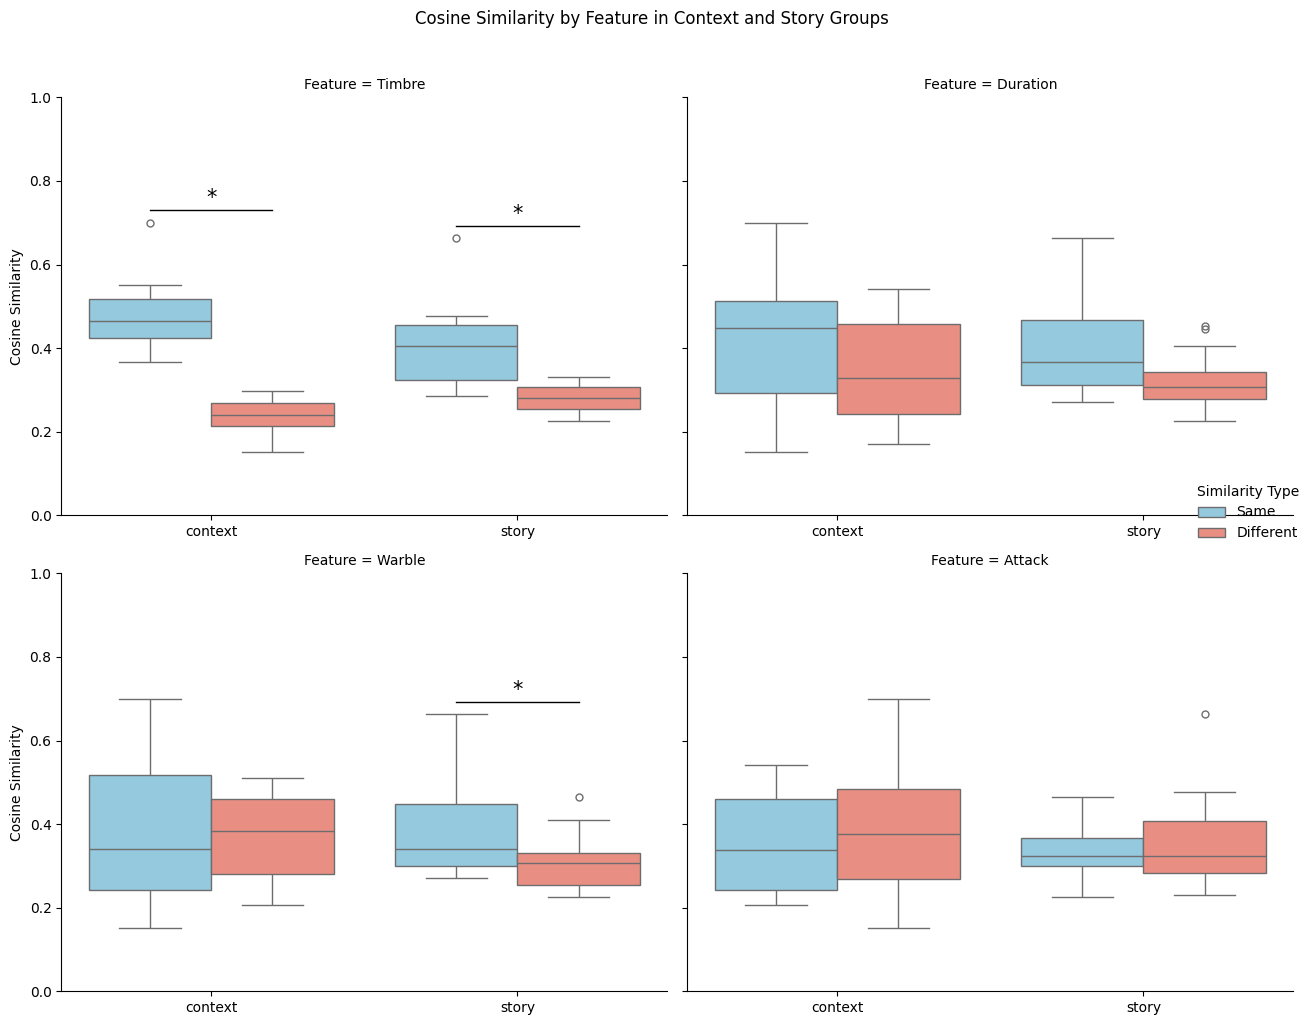

Plot saved to: /content/drive/MyDrive/Single Sounds Study/Combined Results/feature_cosine_similarity_boxplot.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Set up a figure and axes for the plot
plt.figure(figsize=(18, 8)) # Adjust figure size for better readability with multiple subplots

# 2. Create a grouped box plot
# Using `catplot` for faceting by 'Feature' more easily than `boxplot` directly
g = sns.catplot(
    data=combined_plot_df,
    x='Corpus',
    y='Cosine Similarity',
    hue='Similarity Type',
    col='Feature', # This creates separate subplots for each feature
    kind='box',    # Specifies a box plot
    col_wrap=2,    # Wrap columns after 2 plots for better layout
    height=5, aspect=1.2, # Adjust height and aspect ratio of each subplot
    palette={'Same': 'skyblue', 'Different': 'salmon'}
)

# Constants for annotation positioning
hue_spread = 0.2  # Approximate spread for 'Same' and 'Different' boxes around the main x-tick
y_offset = 0.03   # Offset above the max box for the line
text_offset = 0.005 # Offset above the line for the asterisk

# Define the path to save the plot
plot_filepath = os.path.join(results_dir, 'feature_cosine_similarity_boxplot.png')

# 3. Iterate through each subplot to add significance annotations
for i, ax in enumerate(g.axes.flat):
    ax.tick_params(labelbottom=True)
    ax.set_xlabel('') # Corrected: Changed ax.xlabel('') to ax.set_xlabel('')
    # Extract Feature name from the subplot title
    feature_name_display = ax.get_title().split('=')[-1].strip() # e.g., 'Timbre'
    feature_name_for_df = 'same_' + feature_name_display.lower() # e.g., 'same_timbre'

    # Define x-positions for 'context' and 'story' categories on the axis
    x_context_pos = 0
    x_story_pos = 1

    # Annotate for 'context' corpus
    context_p_value = p_values_df[
        (p_values_df['corpus'] == 'context') &
        (p_values_df['feature'] == feature_name_for_df)
    ]['p_value'].iloc[0]

    if context_p_value < 0.05: # Corrected threshold from 0.055 to 0.05
        # Determine max y-value for 'context' data within this feature
        y_max_context = combined_plot_df[
            (combined_plot_df['Feature'] == feature_name_display) &
            (combined_plot_df['Corpus'] == 'context')
        ]['Cosine Similarity'].max()

        y_line_context = y_max_context + y_offset
        ax.plot([x_context_pos - hue_spread, x_context_pos + hue_spread], [y_line_context, y_line_context], color='black', lw=1)
        ax.text(x_context_pos, y_line_context + text_offset, '*', ha='center', va='bottom', color='black', fontsize=15)

    # Annotate for 'story' corpus
    story_p_value = p_values_df[
        (p_values_df['corpus'] == 'story') &
        (p_values_df['feature'] == feature_name_for_df)
    ]['p_value'].iloc[0]

    if story_p_value < 0.05: # Corrected threshold from 0.055 to 0.05
        # Determine max y-value for 'story' data within this feature
        y_max_story = combined_plot_df[
            (combined_plot_df['Feature'] == feature_name_display) &
            (combined_plot_df['Corpus'] == 'story')
        ]['Cosine Similarity'].max()

        y_line_story = y_max_story + y_offset
        ax.plot([x_story_pos - hue_spread, x_story_pos + hue_spread], [y_line_story, y_line_story], color='black', lw=1)
        ax.text(x_story_pos, y_line_story + text_offset, '*', ha='center', va='bottom', color='black', fontsize=15)

# 4. Add a title to the overall figure
g.fig.suptitle('Cosine Similarity by Feature in Context and Story Groups', y=1.02) # Adjust y to move title up

# 5. Adjust the layout to prevent labels from overlapping
plt.tight_layout()
plt.ylim(0,1)
plt.ylabel('Cosine Similarity')

# Save the figure
g.savefig(plot_filepath)
plt.show()
print(f"Plot saved to: {plot_filepath}")

In [ ]:
# Group by Corpus, Feature, and Similarity Type, then calculate mean and standard deviation
summary_stats = combined_plot_df.groupby(['Corpus', 'Feature', 'Similarity Type'])['Cosine Similarity'].agg(['mean', 'std'])

print("Mean and Standard Deviation of Cosine Similarity for each comparison:")
print(summary_stats)


Mean and Standard Deviation of Cosine Similarity for each comparison:
                                      mean       std
Corpus  Feature  Similarity Type                    
context Attack   Different        0.385421  0.151622
                 Same             0.356632  0.123557
        Duration Different        0.343208  0.120891
                 Same             0.412916  0.155479
        Timbre   Different        0.236898  0.045526
                 Same             0.475222  0.084133
        Warble   Different        0.370466  0.104678
                 Same             0.375046  0.162844
story   Attack   Different        0.357855  0.111560
                 Same             0.339020  0.076891
        Duration Different        0.317624  0.069324
                 Same             0.392662  0.114198
        Timbre   Different        0.280572  0.036793
                 Same             0.401692  0.096147
        Warble   Different        0.309537  0.071480
                 Same        

In [ ]:
print(p_values_df)

    corpus        feature       p_value    t_stat         df
0  context    same_timbre  1.060759e-09  9.609249  24.008515
1    story    same_timbre  1.626449e-04  4.609028  20.370351
2  context  same_duration  2.122227e-01  1.288259  20.192462
3    story  same_duration  6.005773e-02  2.014750  16.970118
4  context    same_warble  9.287253e-01  0.090336  25.518745
5    story    same_warble  4.422815e-02  2.115060  25.838250
6  context    same_attack  5.849408e-01 -0.553131  25.771323
7    story    same_attack  6.017060e-01 -0.528429  25.867940
